## Registration of Points in memory

Demonstrates how to use the points of a pair of itk.PointSet objects as input to a registration

In [1]:
import itk

# Generate the corner points of a unit square (1x1 square).
def make_square(origin_x, origin_y):
    point_set = itk.PointSet[itk.UC, 2].New()
    points = point_set.GetPoints().CastToSTLContainer()

    for x in (0, 1):
        for y in (0, 1):
            points.push_back((origin_x + x, origin_y + y))

    return point_set


In [2]:
def plot_point_sets(point_sets):

    import matplotlib.pyplot as plt

    figure = plt.figure()
    axes = plt.axes()
    axes.set_xlim(0, 8)
    axes.set_ylim(0, 5)

    for point_set in point_sets:
        index_range = range(0, point_set.GetNumberOfPoints())
        axes.scatter(
            [point_set.GetPoint(i)[0] for i in index_range],
            [point_set.GetPoint(i)[1] for i in index_range],
        )


In [3]:
fixed_point_set = make_square(3, 3)
moving_point_set = make_square(6, 1)


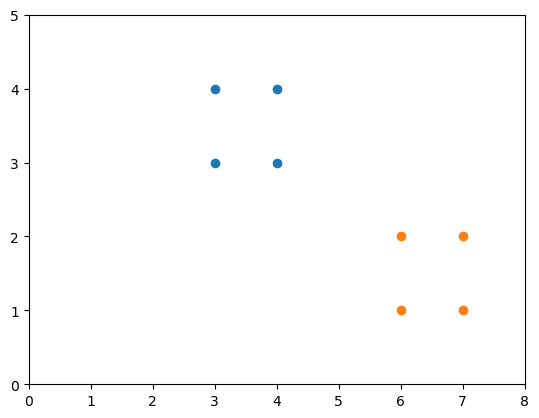

In [4]:
plot_point_sets((fixed_point_set, moving_point_set))

In [5]:
dimension = 2
ImageType = itk.Image[itk.SS, dimension]

dummy_image = ImageType.New()
dummy_image.SetRegions(itk.Size[dimension].Filled(8))
dummy_image.AllocateInitialized()

parameter_object = itk.ParameterObject.New()
parameter_object.AddParameterMap(
    {"ImageSampler": ("Full",),
    "MaximumNumberOfIterations": ("16",),
    "Metric": ("AdvancedNormalizedCorrelation", "CorrespondingPointsEuclideanDistanceMetric"),
    "Optimizer": ("AdaptiveStochasticGradientDescent",),
    "Registration": ( "MultiMetricMultiResolutionRegistration",),
    "Transform": ("TranslationTransform",)})

registration = itk.ElastixRegistrationMethod.New(
    fixed_image=dummy_image,
    moving_image=dummy_image,
    parameter_object=parameter_object,
    fixed_points=fixed_point_set.GetPoints(),
    moving_points=moving_point_set.GetPoints())
registration.Update()

transform = registration.GetNthTransform(0)
print('Detected translation: ', itk.GetArrayViewFromVnlVector(transform.GetParameters()))

transformed_point_set = itk.PointSet[itk.UC, dimension].New()

for i in range(0, fixed_point_set.GetNumberOfPoints()):
    transformed_point = transform.TransformPoint(fixed_point_set.GetPoint(i))
    transformed_point_set.SetPoint(i, transformed_point)
    

Detected translation:  [ 2.98161544 -1.98774363]


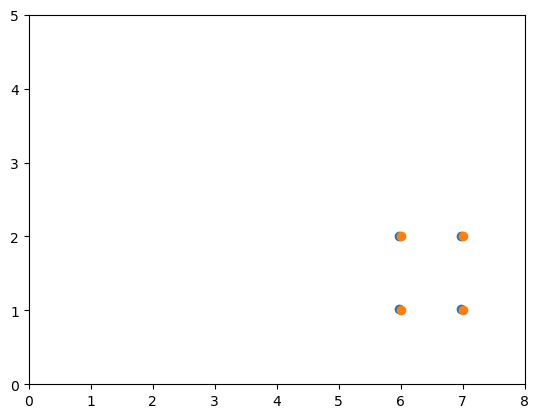

In [6]:
plot_point_sets((transformed_point_set, moving_point_set))